<a href="https://colab.research.google.com/github/onishiryo/KeiRikiKiso/blob/main/Day3_%E5%AE%9A%E5%B8%B8%E5%8F%8D%E5%BE%A9%E6%B3%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2次元ポワソン方程式の解法（定常反復法）
$$
\frac{d^2 T(x,y)}{dx^2} + \frac{d^2 T(x,y)}{dy^2}=q(x,y)
$$
$$0\leq x \leq L_x (=\pi), 0\leq y \leq L_y (=\pi), q(x,y)=\mathrm{sin}(x)\mathrm{sin}(y)$$
境界条件：$$T(x=0,L_x)=0, T(y=0, L_y)=0$$
を解く。
解析解は
$$
T(x,y)=-\frac{1}{2}\mathrm{sin}(x) \mathrm{sin}(y)
$$

# ヤコビ法

反復回数: 1007
L1ノルム誤差: 9.960013121427386e-07


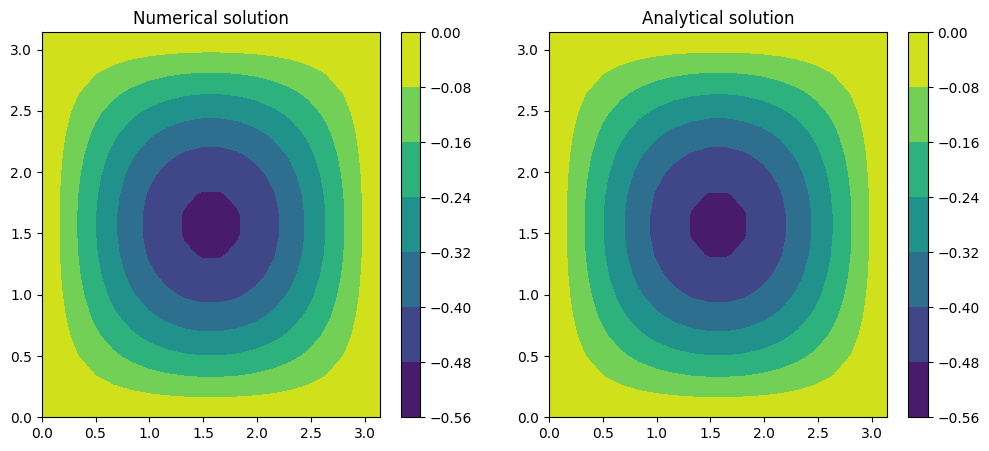

In [14]:
# prompt: 2次元ポワソン方程式を中心差分法を使って解くコード。発熱量q(x,y)=sin(x)sin(y)で与えられるときの、温度Tの2次元分布を求める。ヤコビ法を使う。説明は日本語で書く。T(x,y)をプロットする。解析解もプロットする。反復回数も出力する。L1ノルム誤差も出力する。numpyを使ってはいけない。描画にだけnumpyを使って良い。

import matplotlib.pyplot as plt
import math

# 定数
Lx = math.pi
Ly = math.pi
nx = 20  # x方向の格子点数
ny = 20  # y方向の格子点数
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)
tolerance = 1e-6  # 収束判定のための許容誤差
max_iterations = 10000  # 最大反復回数

# 発熱量q(x,y)
def q(x, y):
  return math.sin(x) * math.sin(y)

# 解析解T(x,y)
def analytical_solution(x, y):
  return -0.5 * math.sin(x) * math.sin(y)


# ヤコビ法による反復計算
T = [[0.0 for _ in range(ny)] for _ in range(nx)]  # 温度分布
T_new = [[0.0 for _ in range(ny)] for _ in range(nx)] #次のステップの温度分布
iterations = 0

while iterations < max_iterations:
  iterations += 1
  l1_norm_error = 0
  for i in range(1, nx - 1):
    for j in range(1, ny - 1):
      # 値を更新
      T_new[i][j] = (-dx**2 * dy**2 * q(i * dx, j * dy) + \
                      dy**2 * (T[i+1][j] + T[i-1][j]) + \
                      dx**2 * (T[i][j+1] + T[i][j-1])) / (2 * (dx**2 + dy**2))

      l1_norm_error += abs(T_new[i][j] - T[i][j])


  # 収束判定
  if l1_norm_error < tolerance:
    break
  # Tを更新
  for i in range(1, nx - 1):
      for j in range(1, ny - 1):
          T[i][j] = T_new[i][j]


print(f"反復回数: {iterations}")
print(f"L1ノルム誤差: {l1_norm_error}")

# 結果のプロット ==============================================
x = [i * dx for i in range(nx)]
y = [j * dy for j in range(ny)]

#数値解
T_num = [[T[i][j] for j in range(ny)] for i in range(nx)]
#解析解
T_ana = [[analytical_solution(i*dx,j*dy) for j in range(ny)] for i in range(nx)]

import numpy as np

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
CS = ax1.contourf(X,Y,np.array(T_num))
ax1.set_title('Numerical solution')
fig.colorbar(CS)

ax2 = fig.add_subplot(1,2,2)
CS = ax2.contourf(X,Y,np.array(T_ana))
ax2.set_title('Analytical solution')
fig.colorbar(CS)


plt.show()

# Jacobi法への緩和係数omegaの導入
緩和係数omegaを導入しよう。

omega=0.0, 0.5, 1.0, 1.8として、収束解を得られるか試してみよう。

# SOR法
Jacobi法と違う箇所を確認しよう
omega>1で繰り返し回数が減少する（スピードアップする）様子を確かめよう。
omega=1のときがガウス・ザイデル法

反復回数: 79
L1ノルム誤差: 8.120972098436818e-07


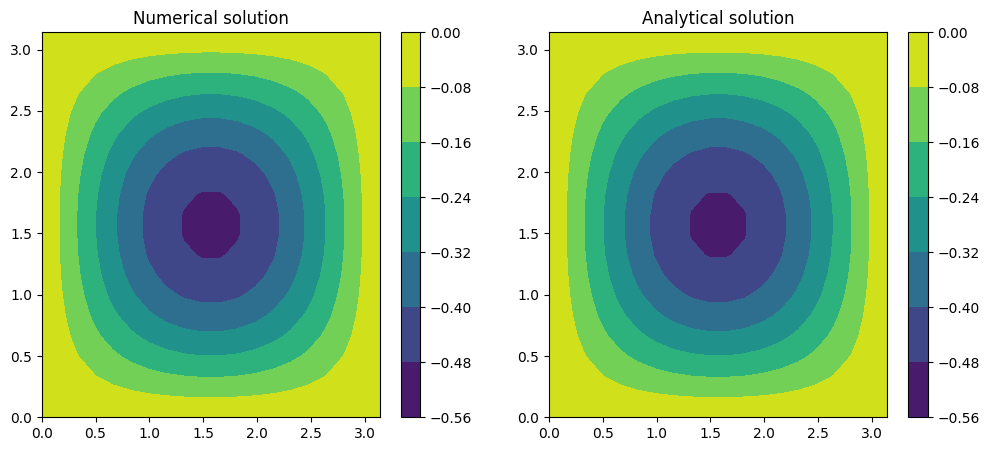

In [22]:
# prompt: 2次元ポワソン方程式を中心差分法を使って解くコード。発熱量q(x,y)=sin(x)sin(y)で与えられるときの、温度Tの2次元分布を求める。SOR法を使う。説明は日本語で書く。T(x,y)をプロットする。解析解もプロットする。反復回数も出力する。L1ノルム誤差も出力する。numpyを使ってはいけない。描画にだけnumpyを使って良い。

import matplotlib.pyplot as plt
import math

# 定数
Lx = math.pi
Ly = math.pi
nx = 20  # x方向の格子点数
ny = 20  # y方向の格子点数
dx = Lx / (nx - 1)
dy = Ly / (ny - 1)
tolerance = 1e-6  # 収束判定のための許容誤差
max_iterations = 10000  # 最大反復回数
omega = 1.8 # SOR法の緩和係数

# 発熱量q(x,y)
def q(x, y):
  return math.sin(x) * math.sin(y)

# 解析解T(x,y)
def analytical_solution(x, y):
  return -0.5 * math.sin(x) * math.sin(y)

# SOR法による反復計算
T = [[0.0 for _ in range(ny)] for _ in range(nx)]  # 温度分布
T_new = [[0.0 for _ in range(ny)] for _ in range(nx)] #次のステップの温度分布
iterations = 0

while iterations < max_iterations:
    iterations += 1
    l1_norm_error = 0
    for i in range(1, nx - 1):
        for j in range(1, ny - 1):
            # SOR法の更新式
            # T_new[i][j] = (-dx**2 * dy**2 * q(i * dx, j * dy) + \
            #           dy**2 * (T[i+1][j] + T[i-1][j]) + \
            #           dx**2 * (T[i][j+1] + T[i][j-1])) / (2 * (dx**2 + dy**2))
            T_new[i][j] = (1 - omega) * T[i][j] + \
                      omega * (-dx**2 * dy**2 * q(i * dx, j * dy) + \
                      dy**2 * (T[i+1][j] + T_new[i-1][j]) + \
                      dx**2 * (T[i][j+1] + T_new[i][j-1])) / (2 * (dx**2 + dy**2))
            l1_norm_error += abs(T_new[i][j] - T[i][j])

    # 収束判定
    if l1_norm_error < tolerance:
        break
    # Tを更新
    for i in range(1, nx - 1):
      for j in range(1, ny - 1):
          T[i][j] = T_new[i][j]

print(f"反復回数: {iterations}")
print(f"L1ノルム誤差: {l1_norm_error}")

# 結果のプロット
import numpy as np
x = [i * dx for i in range(nx)]
y = [j * dy for j in range(ny)]

#数値解
T_num = [[T[i][j] for j in range(ny)] for i in range(nx)]
#解析解
T_ana = [[analytical_solution(i*dx,j*dy) for j in range(ny)] for i in range(nx)]

X, Y = np.meshgrid(x, y)

fig = plt.figure(figsize=(12,5))

ax1 = fig.add_subplot(1,2,1)
CS = ax1.contourf(X,Y,np.array(T_num))
ax1.set_title('Numerical solution')
fig.colorbar(CS)

ax2 = fig.add_subplot(1,2,2)
CS = ax2.contourf(X,Y,np.array(T_ana))
ax2.set_title('Analytical solution')
fig.colorbar(CS)

plt.show()